### Mounting drive and createing folders for checkpoints and artifacts

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/DeepfakeAudio'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, 'checkpoints'),exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, 'artifacts'), exist_ok=True)

print(f"Project directory ready: {PROJECT_DIR}")
print(os.listdir(PROJECT_DIR))

Mounted at /content/drive
Project directory ready: /content/drive/MyDrive/DeepfakeAudio
['checkpoints', 'artifacts']


In [3]:
!pip install -q torchaudio librosa kaggle scikit-learn matplotlib

import torch, torchaudio, librosa, sklearn, numpy as np, matplotlib, random
print(f"torch: {torch.__version__}")
print(f"torchaudio: {torchaudio.__version__}")
print(f"CUDA available: {torch.cuda.is_available}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"}")

torch: 2.11.0+cpu
torchaudio: 2.11.0+cpu
CUDA available: <function is_available at 0x791bfcc3dee0>
Device: CPU only


In [4]:
SEED = 42

def set_seed(seed=SEED):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

set_seed()

### Getting Kaggle Dataset

In [5]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [6]:
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [7]:
DATA_DIR = '/content/data'
os.makedirs(DATA_DIR, exist_ok=True)

!kaggle datasets download -d mohammedabdeldayem/the-fake-or-real-dataset -p {DATA_DIR}
!unzip -q {DATA_DIR}/the-fake-or-real-dataset.zip -d {DATA_DIR}

Dataset URL: https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset
License(s): GNU Lesser General Public License 3.0
100% 16.0G/16.0G [02:22<00:00, 120MB/s]



In [8]:
TRAIN_DIR = os.path.join(DATA_DIR, 'for-norm', 'for-norm', 'training')
REAL_DIR = os.path.join(TRAIN_DIR, 'real')
FAKE_DIR = os.path.join(TRAIN_DIR, 'fake')

real_files = [os.path.join(REAL_DIR, f) for f in os.listdir(REAL_DIR)]
fake_files = [os.path.join(FAKE_DIR, f) for f in os.listdir(FAKE_DIR)]

print(f"Real: {len(real_files)}")
print(f"Fake: {len(fake_files)}")
print(f"Total: {len(real_files)+len(fake_files)}")

print("Sample real:", real_files[0])
print("Sample fake:", fake_files[0])

Real: 26941
Fake: 26927
Total: 53868
Sample real: /content/data/for-norm/for-norm/training/real/file28302.wav_16k.wav_norm.wav_mono.wav_silence.wav
Sample fake: /content/data/for-norm/for-norm/training/fake/file609.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav


### EDA

In [9]:
def quick_probe(path):
  wav, sr = torchaudio.load(path)
  return wav.shape, sr, wav.shape[1]/sr

for p in random.sample(real_files, 3) + random.sample(fake_files, 3):
  shape, sr, dur = quick_probe(p)
  print(f"{os.path.basename(p)[:30]:32} shape={shape} sr={sr} dur={dur:.2f}s")

file28903.wav_16k.wav_norm.wav   shape=torch.Size([1, 52603]) sr=16000 dur=3.29s
file23515.wav_16k.wav_norm.wav   shape=torch.Size([1, 99981]) sr=16000 dur=6.25s
file7760.wav_16k.wav_norm.wav_   shape=torch.Size([1, 43500]) sr=16000 dur=2.72s
file25313.mp3.wav_16k.wav_norm   shape=torch.Size([1, 13569]) sr=16000 dur=0.85s
file18701.mp3.wav_16k.wav_norm   shape=torch.Size([1, 32794]) sr=16000 dur=2.05s
file13434.wav_16k.wav_norm.wav   shape=torch.Size([1, 17711]) sr=16000 dur=1.11s


600
min. duration: 0.47s
max. duration: 11.86s
mean duration: 3.07s
median duration: 2.38s


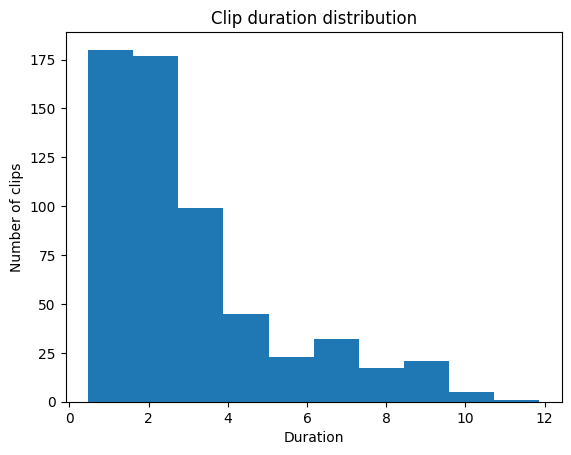

In [10]:
import matplotlib.pyplot as plt

durations = []
for p in random.sample(real_files, 300) + random.sample(fake_files, 300):
  try:
    dur = librosa.get_duration(path=p)
    durations.append(dur)
  except Exception as e:
    print(f"Bad file:", p, e)

durations = np.array(durations)
print(len(durations))
print(f"min. duration: {durations.min():.2f}s")
print(f"max. duration: {durations.max():.2f}s")
print(f"mean duration: {durations.mean():.2f}s")
print(f"median duration: {np.median(durations):.2f}s")

plt.hist(durations)
plt.title('Clip duration distribution')
plt.xlabel('Duration')
plt.ylabel('Number of clips')
plt.show()

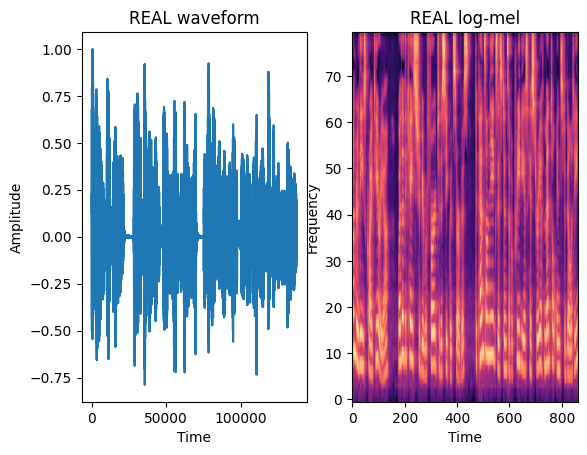

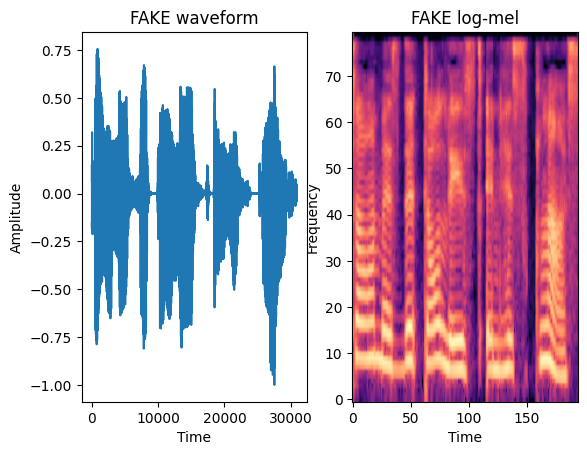

In [11]:
def show_audio(path, title):
  wav, sr = torchaudio.load(path)
  wav = wav.mean(0)
  mel = torchaudio.transforms.MelSpectrogram(sample_rate=sr, n_fft=512,hop_length=160,n_mels=80)(wav.unsqueeze(0))
  logmel = torch.log(mel+1e-6).squeeze(0)

  fig, ax = plt.subplots(1,2)
  ax[0].plot(wav.numpy())
  ax[0].set_xlabel('Time')
  ax[0].set_ylabel('Amplitude')
  ax[0].set_title(f"{title} waveform")

  ax[1].imshow(logmel.numpy(),origin='lower',aspect='auto',cmap='magma')
  ax[1].set_xlabel('Time')
  ax[1].set_ylabel('Frequency')
  ax[1].set_title(f"{title} log-mel")

  plt.show()

show_audio(random.choice(real_files), 'REAL')
show_audio(random.choice(fake_files), 'FAKE')

### Preprocessing

In [12]:
import json

CONFIG = {
    'sample_rate': 16000,
    'n_samples': int(16000*2.5),
    'duration_sec': 2.5,
    'n_fft': 512,
    'hop_length': 160,
    'n_mels': 80,
    'fmin': 20,
    'fmax': 8000,
    'log_offset': 1e-6,
    'seed': 42
}

CONFIG_PATH = os.path.join(PROJECT_DIR, 'artifacts', 'config.json')

with open(CONFIG_PATH, 'w') as f:
  json.dump(CONFIG, f, indent=2)

print(json.dumps(CONFIG, indent=2))

{
  "sample_rate": 16000,
  "n_samples": 40000,
  "duration_sec": 2.5,
  "n_fft": 512,
  "hop_length": 160,
  "n_mels": 80,
  "fmin": 20,
  "fmax": 8000,
  "log_offset": 1e-06,
  "seed": 42
}


In [13]:
def load_audio_fixed(path, cfg, training=False):
  # Loading mono audio at target sample_rate and fixing it to n_samples by either padding or cropping
  y,_ = librosa.load(path, sr=cfg['sample_rate'],mono=True)
  n = cfg['n_samples']

  if (len(y)<n): # pad short clips
    y = np.pad(y,(0,n-len(y)), mode='constant')

  elif (len(y)>n): # crop long clips
    if training:
      start = np.random.randint(0,len(y)-n+1)
    else:
      start = (len(y)-n)//2

    y = y[start:start+n]

  peak = np.max(np.abs(y)) # peak normalization
  if (peak>0):
    y = y/peak

  return y.astype(np.float32)


In [36]:
def audio_to_logmel(y, cfg):
  mel = librosa.feature.melspectrogram(
    y = y,
    sr = cfg['sample_rate'],
    n_fft = cfg['n_fft'],
    hop_length = cfg['hop_length'],
    n_mels = cfg['n_mels'],
    fmin = cfg['fmin'],
    fmax = cfg['fmax'],
  )
  logmel = np.log(mel+cfg['log_offset'])
  return logmel.astype(np.float32)

waveform sample: (40000,)
log-mel shape: (80, 251)
log-mel range: -13.803784370422363-3.875551462173462


Text(0.5, 1.0, 'Verified logmel')

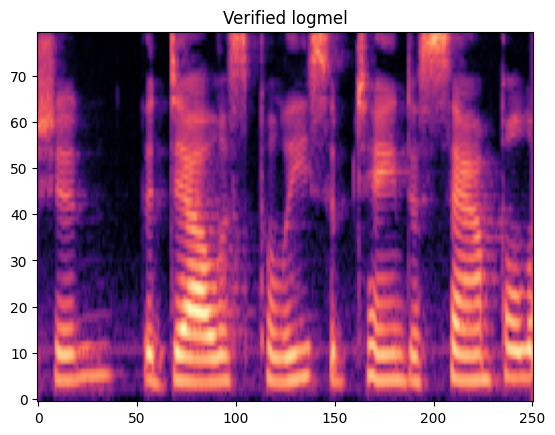

In [37]:
p = random.choice(real_files)
y = load_audio_fixed(p, CONFIG, training=False)
logmel = audio_to_logmel(y, CONFIG)

print(f"waveform sample: {y.shape}")
print(f"log-mel shape: {logmel.shape}")
print(f"log-mel range: {logmel.min()}-{logmel.max()}")

plt.imshow(logmel, origin='lower', aspect='auto', cmap='magma')
plt.title('Verified logmel')

In [38]:
from sklearn.model_selection import train_test_split

all_paths = real_files + fake_files
all_labels = [0]*len(real_files) + [1]*len(fake_files)

train_paths, val_paths, train_labels, val_labels = train_test_split(all_paths, all_labels, test_size=0.15, random_state=42)

print(f"Train: {len(train_paths)}   Val: {len(val_paths)}")
print(f"Train real/fake: {train_labels.count(0)}/{train_labels.count(0)}")
print(f"Val real/fake: {val_labels.count(0)}/{val_labels.count(0)}")

Train: 45787   Val: 8081
Train real/fake: 22982/22982
Val real/fake: 3959/3959


In [39]:
def augment_waveform(y, cfg):
  # gausian noise at random SNR
  if np.random.rand()<0.5:
    snr_db = np.random.uniform(10,30)
    rms = np.sqrt(np.mean(y**2)) + 1e-9
    noise_rms = rms/(10**(snr_db/20))
    y = y+np.random.normal(0,noise_rms,len(y)).astype(np.float32)
  # random gain
  if np.random.rand() < 0.5:
    y = y*np.random.uniform(0.7,1.3)
  return np.clip(y, -1.0,1.0).astype(np.float32)

def augment_spec(logmel, cfg, n_freq=2,n_time=2,max_f=12,max_t=20):
  spec = logmel.copy()
  n_mels, T = spec.shape
  fill = spec.min()

  for _ in range(n_freq):
    f = np.random.randint(0,max_f)
    f0 = np.random.randint(0, max(1,n_mels-f))
    spec[f0:f0+f, :] = fill

  for _ in range(n_time):
    t = np.random.randint(0, max_t)
    t0 = np.random.randint(0, max(1, T-t))
    spec[:, t0:t0+t] = fill
  return spec

In [44]:
import torch
from torch.utils.data import Dataset

class DeepfakeAudioDataset(Dataset):
  def __init__(self, paths, labels, cfg, training=False):
    self.paths  = paths
    self.labels = labels
    self.cfg = cfg
    self.training = training

  def __len__(self):
    return len(self.paths)

  def __getitem__(self, idx):
    path, label = self.paths[idx], self.labels[idx]
    try:
      y = load_audio_fixed(path, self.cfg, training=self.training)
      if self.training:
        y = augment_waveform(y, self.cfg)
      logmel = audio_to_logmel(y, self.cfg)
      if self.training:
        logmel = augment_spec(logmel, self.cfg)

    except Exception as e:
      print(f"[Data Warning] {os.path.basename(path)}: {type(e).__name__}: {e}")
      logmel = np.zeros((self.cfg['n_mels'], 1+self.cfg['n_samples']//self.cfg['hop_length']), dtype=np.float32)

    x = torch.from_numpy(logmel).unsqueeze(0)
    return x, torch.tensor(label, dtype=torch.long)

In [45]:
from torch.utils.data import DataLoader

train_ds = DeepfakeAudioDataset(train_paths, train_labels, CONFIG, training=True)
val_ds   = DeepfakeAudioDataset(val_paths,   val_labels,   CONFIG, training=False)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=True)
print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))

Train batches: 715 | Val batches: 127


In [46]:
xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape, "(expected [64, 1, 80, ~251])")
print("Batch y:", yb.shape, "| labels in batch:", yb.unique(return_counts=True))
print("X dtype:", xb.dtype, "| range:", xb.min().item(), "to", xb.max().item())

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch X: torch.Size([64, 1, 80, 251]) (expected [64, 1, 80, ~251])
Batch y: torch.Size([64]) | labels in batch: (tensor([0, 1]), tensor([40, 24]))
X dtype: torch.float32 | range: -13.815510749816895 to 5.491510391235352


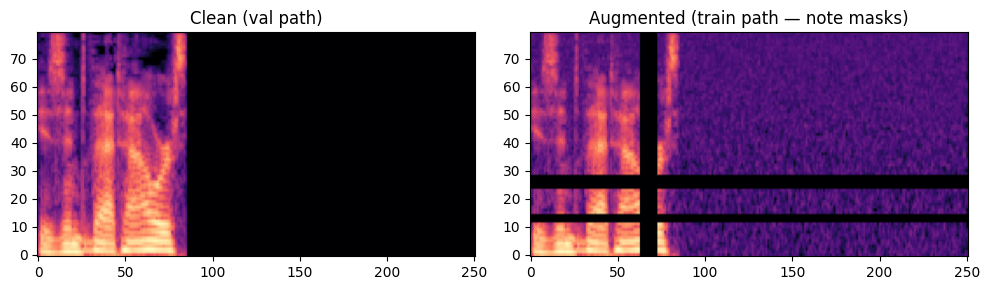

In [47]:
import matplotlib.pyplot as plt

# pull the SAME file through both paths to see augmentation effect
ds_aug   = DeepfakeAudioDataset([train_paths[0]], [train_labels[0]], CONFIG, training=True)
ds_clean = DeepfakeAudioDataset([train_paths[0]], [train_labels[0]], CONFIG, training=False)

fig, ax = plt.subplots(1, 2, figsize=(10,3))
ax[0].imshow(ds_clean[0][0].squeeze(), origin="lower", aspect="auto", cmap="magma")
ax[0].set_title("Clean (val path)")
ax[1].imshow(ds_aug[0][0].squeeze(), origin="lower", aspect="auto", cmap="magma")
ax[1].set_title("Augmented (train path — note masks)")
plt.tight_layout(); plt.show()

### CNN Model

In [50]:
import torch.nn as nn

class DeepfakeCNN(nn.Module):
  def __init__(self, n_classes=2):
    super().__init__()
    def block(input, output):
      return nn.Sequential(
          nn.Conv2d(input, output, kernel_size=3, padding=1),
          nn.BatchNorm2d(output),
          nn.ReLU(inplace=True),
          nn.MaxPool2d(2)
      )
    self.features = nn.Sequential(
        block(1,16),
        block(16,32),
        block(32,64),
        block(64,128)
    )
    self.pool = nn.AdaptiveAvgPool2d(1)
    self.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(128, n_classes)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.pool(x).flatten(1)
    return self.classifier(x)